### Step 1 — Import NumPy

**Purpose:** Load NumPy for numerical arrays and mathematical operations.

**Concept:** The dataset and model parameters are represented as NumPy arrays throughout the notebook.


In [14]:
import numpy as np

### Step 2 — Load the Polynomial Gradient-Descent Implementation

This cell enables autoreload and imports the functions from `poly_gradient.py`.

**Important:** The Python implementation is used as-is. This notebook only calls its existing functions.

**Main workflow:** polynomial features → mini-batch gradient descent → prediction → \(R^2\).


In [15]:
%load_ext autoreload
%autoreload 2

from poly_gradient import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Step 3 — Generate the Nonlinear Dataset

The input contains 60 equally spaced values:

$[
X_i \in [0,\pi].
]$

The target is generated from three sinusoidal components plus controlled random noise:

$[
y=\sin(X)+\sin(3X)+\sin(2X)+\epsilon
]$

with

$[
\epsilon=0.8(U-0.5),\qquad U\sim\mathrm{Uniform}(0,1).
]$

Thus the noise lies in approximately $([-0.4,0.4))$.

The random seed makes the generated dataset reproducible.

**Steps:** generate \(X\) → store its minimum and maximum → generate the nonlinear signal → add random noise.


In [16]:
X = np.linspace(0, 1 * np.pi, 60)
X_min = np.min(X)
X_max = np.max(X)

np.random.seed(42)

y = (
    np.sin(X)
    + np.sin(3 * X)
    + np.sin(2 * X)
    + (np.random.random(len(X)) - 0.5)*0.8
)

### Step 4 — Visualize the Dataset

The scatter plot shows the observed pairs \((X_i,y_i)\).

Because the target contains sine functions, the relationship between \(X\) and \(y\) is nonlinear. The plot gives a visual reference before fitting the polynomial model.


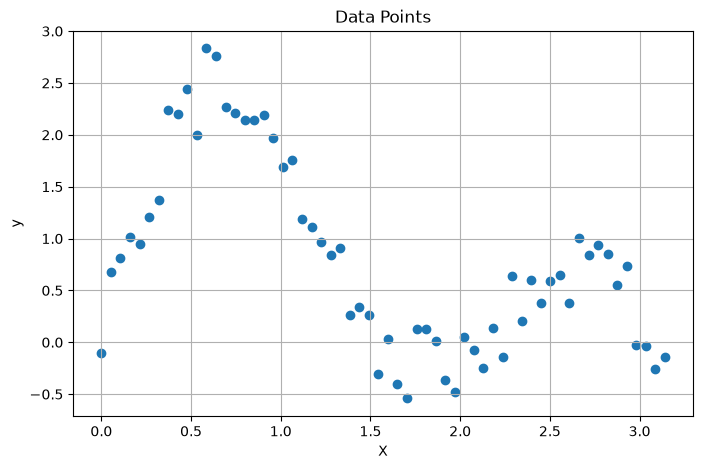

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Data Points")
plt.grid(True)
plt.show()

### Step 5 — Set the Model and Optimization Parameters

The polynomial degree, learning rate, number of epochs, and batch size are fixed here:

$[
d = 5,\qquad
\alpha = 0.01,\qquad
\text{epochs} = 1000,\qquad
m_{\text{batch}} = 1
]$

A degree-\(d\) polynomial has \(d+1\) coefficients because the intercept term is included:

$[
\beta = [\beta_0,\beta_1,\ldots,\beta_d]^T
]$

The learning rate controls the size of each gradient update.


In [18]:
# Model parameters
degree, alpha, epochs, batch_size = 5, 0.01, 1000, 1

### Step 6 — Create Polynomial Features

The existing `create_polynomial_features()` function converts the original input into the polynomial design matrix used by the model.

Conceptually, the columns represent:

$[
1,\ x,\ x^2,\ldots,x^d.
]$

For degree 5, there are six model features:

$[
[1,x,x^2,x^3,x^4,x^5].
]$

The exact feature construction, including any scaling performed by the imported function, is left unchanged.


In [19]:
# Polynomial features
X_poly = create_polynomial_features(X, degree)

### Step 7 — Inspect the Polynomial Feature Shape

This checks the dimensions of the design matrix.

For \(n\) observations and degree \(d\), the expected number of columns is:

$[
d+1.
]$

Here:

$[
n=60,\qquad d=5,
]$

so the feature matrix has 60 rows and 6 columns.


In [20]:
X_poly.shape

(60, 6)

### Step 8 — Initialize the Model Parameters

The parameter vector is initialized with zeros.

For degree 5:

$[
	beta=
[0,0,0,0,0,0]^T.
$]

Before training, this gives the initial model prediction

$[
\hat y=X_{ext{poly}}	beta.
$]

The gradient-descent procedure will update these parameters.


In [21]:
theta = np.zeros(X_poly.shape[1])

### Step 9 — Inspect the Initial Parameters

This displays the initialized coefficient vector.

At this point, no learning has occurred; the coefficients are still the initial values.


In [22]:
theta

array([0., 0., 0., 0., 0., 0.])

### Step 10 — Train with Mini-Batch Gradient Descent

The existing `minibatch_gradient_descent_mlr()` function learns the polynomial coefficients.

For a mini-batch $(X_b,y_b):$

$[
\hat y_b=X_b	beta
]$

and the residual used by the gradient implementation is

$[
r_b=\hat y_b-y_b.
]$

The gradient of the mean-squared-error objective is:

$[
\nabla J(\theta)=\frac{2}{m}X_b^T r_b
]$

The parameters are updated by:

$\boxed{\theta \leftarrow \theta - \alpha \nabla J(\theta)}$

With `batch_size = 1`, one observation is used per parameter update.

**Training steps:** shuffle → form mini-batch → predict → calculate residual → calculate gradient → update $(	beta)$ → repeat.


In [23]:
# Train
theta, loss_history = minibatch_gradient_descent_mlr(
    X_poly, y, theta, alpha, epochs, batch_size
)

Epoch   0 | Loss = 0.6858
Epoch 100 | Loss = 0.2108
Epoch 200 | Loss = 0.1349
Epoch 300 | Loss = 0.1018
Epoch 400 | Loss = 0.0866
Epoch 500 | Loss = 0.0790
Epoch 600 | Loss = 0.0748
Epoch 700 | Loss = 0.0722
Epoch 800 | Loss = 0.0706
Epoch 900 | Loss = 0.0690


### Step 11 — Predict and Evaluate the Fitted Polynomial

After training, the learned parameters are used to calculate predictions:

$[
\hat y=X_{	ext{poly}}	heta.
]$

The notebook then calculates \(R^2\):

$R^2 = 1 - \frac{\sum_i (y_i-\hat{y}_i)^2}{\sum_i (y_i-\bar{y})^2}$

where

$\bar{y} = \frac{1}{n}\sum_i y_i$

A larger $(R^2)$ indicates that the fitted model explains more of the variation in the observed target values.


In [24]:
# Predict and evaluate
y_pred = predict_polynomial(X, theta, degree)
r2_value = r_square(y, y_pred, np.mean(y))

### Step 12 — Display the Polynomial Regression Results

This cell reports the selected polynomial degree, the learned coefficient vector \(	heta\), and the resulting \(R^2\).

The learned polynomial is represented by

$\hat{y} = \theta_0 + \theta_1x + \theta_2x^2 + \cdots + \theta_dx^d$

subject to the exact feature representation used by the existing Python function.


In [25]:
print("POLYNOMIAL REGRESSION RESULTS")


print("Degree:", degree)
print("Theta:", theta)
print("\nR2: ", r2_value)

POLYNOMIAL REGRESSION RESULTS
Degree: 5
Theta: [ 0.12336337 -2.67584135  6.12735419  3.58352048 -6.61031954 -0.97187792]

R2:  0.9165636774835493


### Step 13 — Plot the Fitted Polynomial Regression

The predictions are ordered according to \(X\) so that the fitted polynomial can be drawn as a continuous curve.

The visualization contains the original data points and the polynomial regression curve:

$\hat{y}(x) = X_{\text{poly}}(x)\theta$

This provides a visual check of how the learned polynomial follows the nonlinear dataset.


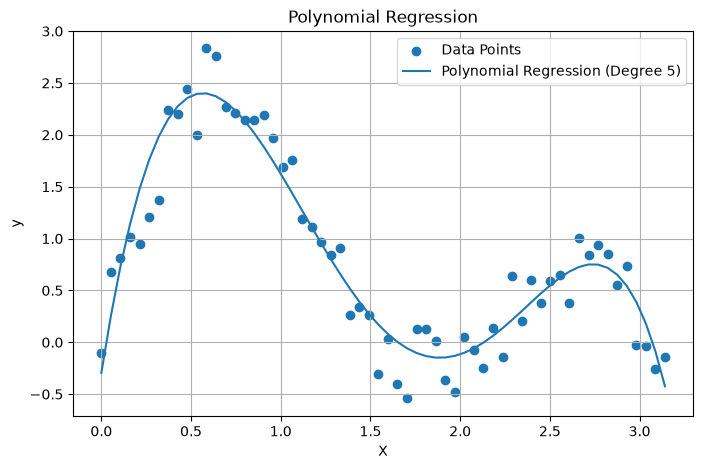

In [26]:
sort_idx = np.argsort(X)
X_sorted, y_sorted_pred = X[sort_idx], y_pred[sort_idx]

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Data Points")
plt.plot(X_sorted, y_sorted_pred, label=f"Polynomial Regression (Degree {degree})")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression")
plt.legend()
plt.grid(True)
plt.show()